In [ ]:
Assignment 7: Variance Explained  
The objective here is to Interpret eigenvalues
Tasks:
•	Perform PCA 
•	Compute: 
o	Explained variance ratio manually 
•	Verify with sklearn output 


# Assignment 7: Computing Explained Variance Ratio from Scratch


## Step 1: Load the Manufacturing Dataset


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

DATA_PATH = '../data/manufacturing_6G_dataset.csv'
FEATURES  = [
    'Temperature_C', 'Vibration_Hz', 'Power_Consumption_kW',
    'Network_Latency_ms', 'Packet_Loss_%', 'Quality_Control_Defect_Rate_%',
    'Production_Speed_units_per_hr', 'Predictive_Maintenance_Score', 'Error_Rate_%'
]

# Load with pandas
df = pd.read_csv(DATA_PATH)
print(f"Raw dataframe shape : {df.shape}")
print(f"\nFirst 3 rows:")
df[FEATURES].head(3)


Raw dataframe shape : (100000, 13)

First 3 rows:


,Temperature_C,Vibration_Hz,Power_Consumption_kW,Network_Latency_ms,Packet_Loss_%,Quality_Control_Defect_Rate_%,Production_Speed_units_per_hr,Predictive_Maintenance_Score,Error_Rate_%
0,74.137590,3.500595,8.612162,10.650542,0.207764,7.751261,477.657391,0.344650,14.965470
1,84.264558,3.355928,2.268559,29.111810,2.228464,4.989172,398.174747,0.769848,7.678270
2,44.280102,2.079766,6.144105,18.357292,1.639416,0.456816,108.074959,0.987086,8.198391


## Step 2: Compute Explained Variance Ratio Manually

The formula is straightforward — divide each eigenvalue by the sum of all eigenvalues:

```
EVR[i] = Lambda_i / sum(all Lambda)
```

Each Lambda equals the variance along that PC direction, so this ratio gives the fraction of total information captured by that component.

In [8]:
# Standardize using pandas then convert to numpy for matrix ops
X_scaled = (df[FEATURES] - df[FEATURES].mean()) / df[FEATURES].std(ddof=1)
X = X_scaled.values   # numpy array shape (100000, 9)

# ── Manual PCA ────────────────────────────────────────────────────────────────
n = X.shape[0]
C = (X.T @ X) / (n - 1)   # covariance matrix (9x9)

eigenvalues, eigenvectors = np.linalg.eig(C)
eigenvalues  = eigenvalues.real
eigenvectors = eigenvectors.real

# Sort descending
order        = np.argsort(eigenvalues)[::-1]
eigenvalues  = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# ── Explained variance ratio (manual) ─────────────────────────────────────────
evr_manual = eigenvalues / eigenvalues.sum()
cumulative  = np.cumsum(evr_manual)

# Display as a clean pandas DataFrame
results_df = pd.DataFrame({
    'PC'           : [f'PC{i+1}' for i in range(len(eigenvalues))],
    'Lambda'       : eigenvalues.round(6),
    'Expl_Var_Ratio': evr_manual.round(6),
    'Cumulative_%' : (cumulative * 100).round(4)
})
results_df = results_df.set_index('PC')
print("Manual PCA — Explained Variance Ratio:")
print(results_df.to_string())

Manual PCA — Explained Variance Ratio:
       Lambda  Expl_Var_Ratio  Cumulative_%
PC                                         
PC1  1.015244        0.112805       11.2805
PC2  1.010063        0.112229       22.5034
PC3  1.006767        0.111863       33.6897
PC4  1.004848        0.111650       44.8547
PC5  1.003155        0.111462       56.0009
PC6  0.994796        0.110533       67.0541
PC7  0.993535        0.110393       78.0934
PC8  0.988176        0.109797       89.0732
PC9  0.983416        0.109268      100.0000


## Step 3: Cross-check Against sklearn

Now I run sklearn's PCA on the same data and compare `explained_variance_ratio_` against my manual values. If the math is right, they should match to several decimal places.

In [9]:
pca_sk = PCA(n_components=len(FEATURES))
pca_sk.fit(X)

evr_sklearn   = pca_sk.explained_variance_ratio_
evals_sklearn = pca_sk.explained_variance_

# Comparison table using pandas
compare_df = pd.DataFrame({
    'PC'           : [f'PC{i+1}' for i in range(len(FEATURES))],
    'Lambda_Manual': eigenvalues.round(6),
    'Lambda_sklearn': evals_sklearn.round(6),
    'EVR_Manual'   : evr_manual.round(6),
    'EVR_sklearn'  : evr_sklearn.round(6),
    'Match'        : ['Yes' if np.isclose(m, s, atol=1e-4) else 'No'
                      for m, s in zip(evr_manual, evr_sklearn)]
}).set_index('PC')

print("Verification — Manual vs sklearn:")
print(compare_df.to_string())
print(f"\nAll EVR values match: {np.allclose(evr_sklearn, evr_manual, atol=1e-4)}")

Verification — Manual vs sklearn:
     Lambda_Manual  Lambda_sklearn  EVR_Manual  EVR_sklearn Match
PC                                                               
PC1       1.015244        1.015244    0.112805     0.112805   Yes
PC2       1.010063        1.010063    0.112229     0.112229   Yes
PC3       1.006767        1.006767    0.111863     0.111863   Yes
PC4       1.004848        1.004848    0.111650     0.111650   Yes
PC5       1.003155        1.003155    0.111462     0.111462   Yes
PC6       0.994796        0.994796    0.110533     0.110533   Yes
PC7       0.993535        0.993535    0.110393     0.110393   Yes
PC8       0.988176        0.988176    0.109797     0.109797   Yes
PC9       0.983416        0.983416    0.109268     0.109268   Yes

All EVR values match: True


## Step 4: Scree Plot

Plotting both the individual and cumulative explained variance. The cumulative curve is the useful one when deciding how many components to keep — I want to find the "elbow" where adding more PCs stops being worth it.

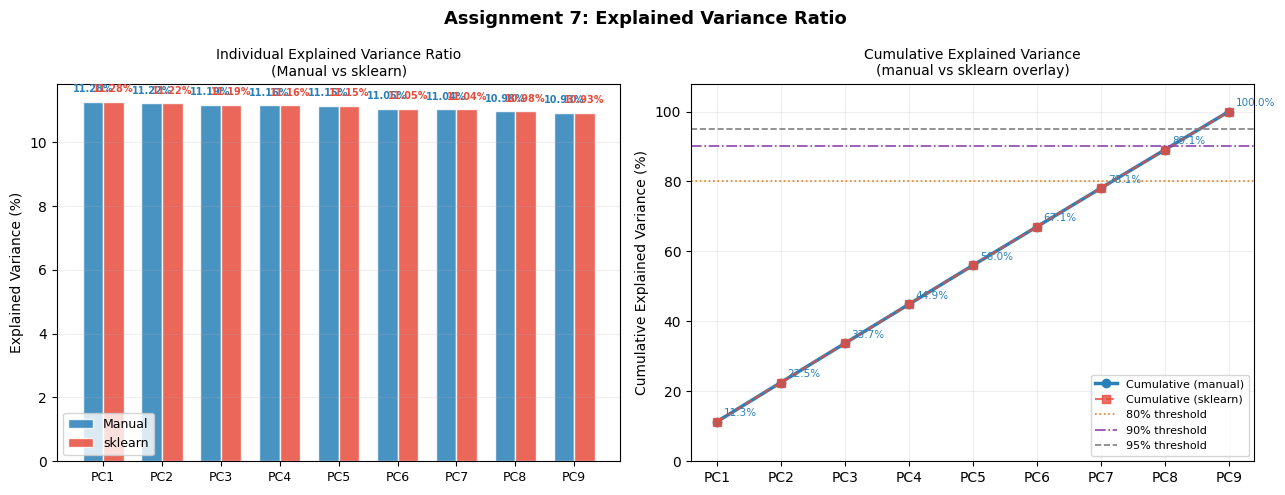

In [10]:
pcs      = [f'PC{i+1}' for i in range(len(FEATURES))]
cum_pct  = cumulative * 100
indv_pct = evr_manual * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: Individual explained variance (manual vs sklearn) ──────────────────
ax = axes[0]
x = np.arange(len(pcs))
w = 0.35
ax.bar(x - w/2, evr_manual  * 100, w, label='Manual',  color='#2980b9', alpha=0.85, edgecolor='white')
ax.bar(x + w/2, evr_sklearn * 100, w, label='sklearn', color='#e74c3c', alpha=0.85, edgecolor='white')

for i, (m, s) in enumerate(zip(evr_manual * 100, evr_sklearn * 100)):
    ax.text(i - w/2, m + 0.3, f'{m:.2f}%', ha='center', fontsize=7, color='#2980b9', fontweight='bold')
    ax.text(i + w/2, s + 0.3, f'{s:.2f}%', ha='center', fontsize=7, color='#e74c3c', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(pcs, fontsize=9)
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Individual Explained Variance Ratio\n(Manual vs sklearn)', fontsize=10)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')

# ── Right: Cumulative variance with threshold lines ───────────────────────────
ax = axes[1]
ax.plot(pcs, cum_pct, 'o-', color='#2980b9', lw=2.5, label='Cumulative (manual)')
ax.plot(pcs, np.cumsum(evr_sklearn) * 100, 's--', color='#e74c3c', lw=1.5,
        label='Cumulative (sklearn)', alpha=0.8)

for thresh, ls, color in [(80, ':', '#e67e22'), (90, '-.', '#8e44ad'), (95, '--', 'gray')]:
    ax.axhline(thresh, color=color, lw=1.2, ls=ls, label=f'{thresh}% threshold')

# Annotate each point with cumulative %
for i, val in enumerate(cum_pct):
    ax.annotate(f'{val:.1f}%', (pcs[i], val),
                textcoords='offset points', xytext=(5, 4), fontsize=7.5, color='#2980b9')

ax.set_ylim(0, 108)
ax.set_ylabel('Cumulative Explained Variance (%)')
ax.set_title('Cumulative Explained Variance\n(manual vs sklearn overlay)', fontsize=10)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.2)

plt.suptitle('Assignment 7: Explained Variance Ratio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/pca_assignment_7_variance_explained.png', dpi=150, bbox_inches='tight')
plt.show()

## What I Learned About Eigenvalues and Variance

| Concept | Formula | Meaning |
|---|---|---|
| **Lambda_i** | — | Variance of data along PC_i |
| **Explained Variance Ratio** | `Lambda_i / Sum(Lambda)` | Fraction of total variance captured by PC_i |
| **Cumulative EVR** | `Sum(Lambda_1..k) / Sum(Lambda)` | Total variance retained by top-k PCs |
| **Total variance** | `Sum(Lambda) = trace(C)` | Equals number of features after standardization |

One thing that tripped me up: after standardizing, the total variance is just the number of features (since each feature has variance = 1). So `Sum(Lambda) = p`. A Lambda > 1 means that PC captures more variance than any single original feature would — that's a useful benchmark when reading a scree plot.